In [1]:
#Week 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global style settings for all plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

In [2]:
df = pd.read_csv("Indian_Kids_Screen_Time.csv")

In [3]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (9712, 8)


In [5]:
print("Columns:", df.columns.tolist())

Columns: ['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device', 'Exceeded_Recommended_Limit', 'Educational_to_Recreational_Ratio', 'Health_Impacts', 'Urban_or_Rural']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [7]:
df.describe()

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226
std,3.162437,1.718232,0.073221
min,8.000000,0.000000,0.300000
25%,10.000000,3.410000,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


In [8]:
df.isnull().sum()

Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64

In [10]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values — {list(df[col].unique()[:5])}")

Age: 11 unique values — [np.int64(14), np.int64(11), np.int64(18), np.int64(15), np.int64(12)]
Gender: 2 unique values — ['Male', 'Female']
Avg_Daily_Screen_Time_hr: 899 unique values — [np.float64(3.99), np.float64(4.61), np.float64(3.73), np.float64(1.21), np.float64(5.89)]
Primary_Device: 4 unique values — ['Smartphone', 'Laptop', 'TV', 'Tablet']
Exceeded_Recommended_Limit: 2 unique values — [np.True_, np.False_]
Educational_to_Recreational_Ratio: 31 unique values — [np.float64(0.42), np.float64(0.3), np.float64(0.32), np.float64(0.39), np.float64(0.49)]
Health_Impacts: 15 unique values — ['Poor Sleep, Eye Strain', 'Poor Sleep', nan, 'Poor Sleep, Anxiety', 'Poor Sleep, Obesity Risk']
Urban_or_Rural: 2 unique values — ['Urban', 'Rural']


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 44


In [12]:
#Week 2
df['Health_Impacts'] = df['Health_Impacts'].fillna("None")
print("Missing after fill:", df.isnull().sum().sum())

Missing after fill: 0


In [13]:
# Ensure correct dtypes
df['Age'] = df['Age'].astype(int)
df['Exceeded_Recommended_Limit'] = df['Exceeded_Recommended_Limit'].astype(bool)
print(df.dtypes)

Age                                    int64
Gender                                object
Avg_Daily_Screen_Time_hr             float64
Primary_Device                        object
Exceeded_Recommended_Limit              bool
Educational_to_Recreational_Ratio    float64
Health_Impacts                        object
Urban_or_Rural                        object
dtype: object


In [14]:
df['Age_Group'] = pd.cut(df['Age'],
                         bins=[5,10,13,16,18],
                         labels=['6-10','11-13','14-16','17-18'])

In [15]:
df['Age_Band'] = pd.cut(df['Age'],
                        bins=[5,10,13,16,18],
                        labels=['Early Childhood (6-10)',
                                'Pre-Teen (11-13)',
                                'Teen (14-16)',
                                'Late Teen (17-18)'])

df[['Age','Age_Band']].head()

,Age,Age_Band
0,14,Teen (14-16)
1,11,Pre-Teen (11-13)
2,18,Late Teen (17-18)
3,15,Teen (14-16)
4,12,Pre-Teen (11-13)


In [16]:
df['Duration_Category'] = pd.cut(df['Avg_Daily_Screen_Time_hr'],
                                 bins=[0,2,4,6,10],
                                 labels=['Low (0-2 hrs)',
                                         'Moderate (2-4 hrs)',
                                         'High (4-6 hrs)',
                                         'Extreme (6+ hrs)'])

df[['Avg_Daily_Screen_Time_hr','Duration_Category']].head()

,Avg_Daily_Screen_Time_hr,Duration_Category
0,3.99,Moderate (2-4 hrs)
1,4.61,High (4-6 hrs)
2,3.73,Moderate (2-4 hrs)
3,1.21,Low (0-2 hrs)
4,5.89,High (4-6 hrs)


In [17]:
mean_screen_time = df['Avg_Daily_Screen_Time_hr'].mean()

df['Day_Type_Flag'] = np.where(df['Avg_Daily_Screen_Time_hr'] > mean_screen_time,
                               'Weekend-like Usage',
                               'Weekday-like Usage')

df[['Avg_Daily_Screen_Time_hr','Day_Type_Flag']].head()

,Avg_Daily_Screen_Time_hr,Day_Type_Flag
0,3.99,Weekday-like Usage
1,4.61,Weekend-like Usage
2,3.73,Weekday-like Usage
3,1.21,Weekday-like Usage
4,5.89,Weekend-like Usage


In [18]:
device_share = df['Primary_Device'].value_counts(normalize=True) * 100
device_share = device_share.round(2)
device_share

Primary_Device
Smartphone    47.03
TV            25.61
Laptop        14.75
Tablet        12.60
Name: proportion, dtype: float64

In [19]:
df['Educational_to_Recreational_Ratio'].describe()

count    9712.000000
mean        0.427226
std         0.073221
min         0.300000
25%         0.370000
50%         0.430000
75%         0.480000
max         0.600000
Name: Educational_to_Recreational_Ratio, dtype: float64

In [20]:
df['Usage_Type'] = pd.cut(
    df['Educational_to_Recreational_Ratio'],
    bins=[0.30, 0.38, 0.48, 0.60],
    labels=['Highly Recreational',
            'Moderately Recreational',
            'Closer to Balanced']
)

df['Usage_Type'].value_counts()

Usage_Type
Moderately Recreational    4633
Highly Recreational        2833
Closer to Balanced         2062
Name: count, dtype: int64

In [21]:
device_time_share = df.groupby('Primary_Device')['Avg_Daily_Screen_Time_hr'].sum()
device_time_share = (device_time_share / device_time_share.sum()) * 100
device_time_share = device_time_share.round(2)
device_time_share

Primary_Device
Laptop        15.12
Smartphone    47.42
TV            25.22
Tablet        12.24
Name: Avg_Daily_Screen_Time_hr, dtype: float64

In [22]:
# Count number of health impacts per child
df['Health_Impact_Count'] = df['Health_Impacts'].apply(
    lambda x: 0 if x == 'None' else len(x.split(','))
)

df['Health_Risk_Level'] = pd.cut(df['Health_Impact_Count'],
                                  bins=[-1, 0, 1, 2, 5],
                                  labels=['No Risk', 'Low Risk', 'Moderate Risk', 'High Risk'])

df[['Health_Impacts','Health_Impact_Count','Health_Risk_Level']].head()

,Health_Impacts,Health_Impact_Count,Health_Risk_Level
0,"Poor Sleep, Eye Strain",2,Moderate Risk
1,Poor Sleep,1,Low Risk
2,Poor Sleep,1,Low Risk
3,None,0,No Risk
4,"Poor Sleep, Anxiety",2,Moderate Risk


In [23]:
df.to_csv("Indian_Kids_Screen_Time_Processed.csv", index=False)
print("Processed dataset saved successfully!")
print("New columns added:", [c for c in df.columns if c not in ['Age','Gender','Avg_Daily_Screen_Time_hr',
                              'Primary_Device','Exceeded_Recommended_Limit',
                              'Educational_to_Recreational_Ratio','Health_Impacts','Urban_or_Rural']])

Processed dataset saved successfully!
New columns added: ['Age_Group', 'Age_Band', 'Duration_Category', 'Day_Type_Flag', 'Usage_Type', 'Health_Impact_Count', 'Health_Risk_Level']


Week 2 Tasks
- `Health_Impacts` null values filled with `'None'`.
- 4 new derived columns: `Age_Group`, `Age_Band`, `Duration_Category`, `Day_Type_Flag`, `Usage_Type`, `Health_Impact_Count`, `Health_Risk_Level`.
- Device time share shows fairly balanced usage across Smartphone, Laptop, Tablet, and TV.
- Processed file saved for reuse in all downstream analyses.

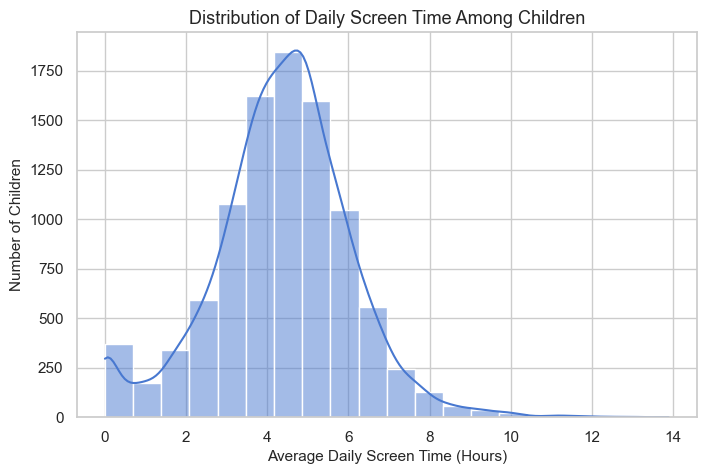

In [24]:
#Week 3
plt.figure(figsize=(8,5))
sns.histplot(df['Avg_Daily_Screen_Time_hr'], bins=20, kde=True)
plt.title("Distribution of Daily Screen Time Among Children")
plt.xlabel("Average Daily Screen Time (Hours)")
plt.ylabel("Number of Children")
plt.show()

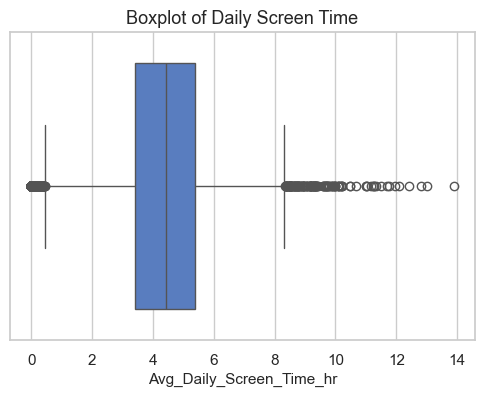

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Avg_Daily_Screen_Time_hr'])
plt.title("Boxplot of Daily Screen Time")
plt.show()

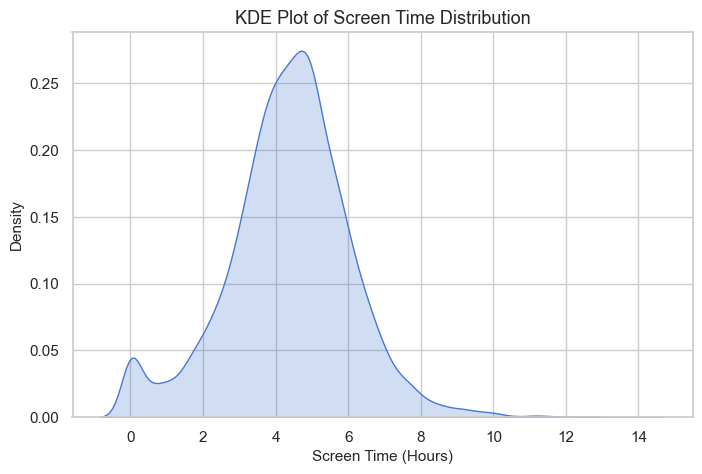

In [26]:
plt.figure(figsize=(8,5))
sns.kdeplot(df['Avg_Daily_Screen_Time_hr'], fill=True)
plt.title("KDE Plot of Screen Time Distribution")
plt.xlabel("Screen Time (Hours)")
plt.ylabel("Density")
plt.show()

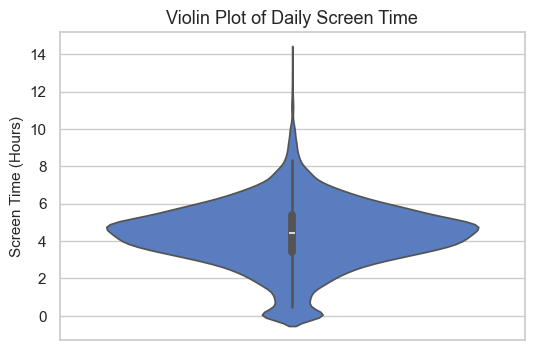

In [27]:
plt.figure(figsize=(6,4))
sns.violinplot(y=df['Avg_Daily_Screen_Time_hr'])
plt.title("Violin Plot of Daily Screen Time")
plt.ylabel("Screen Time (Hours)")
plt.show()

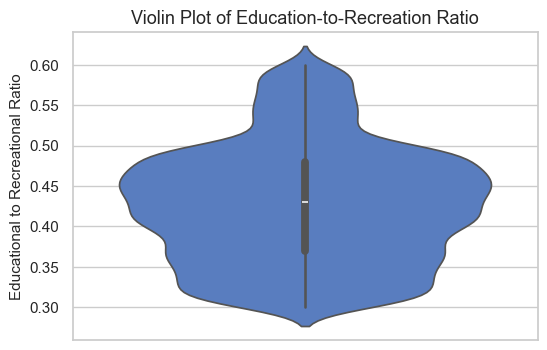

In [28]:
plt.figure(figsize=(6,4))
sns.violinplot(y=df['Educational_to_Recreational_Ratio'])
plt.title("Violin Plot of Education-to-Recreation Ratio")
plt.ylabel("Educational to Recreational Ratio")
plt.show()

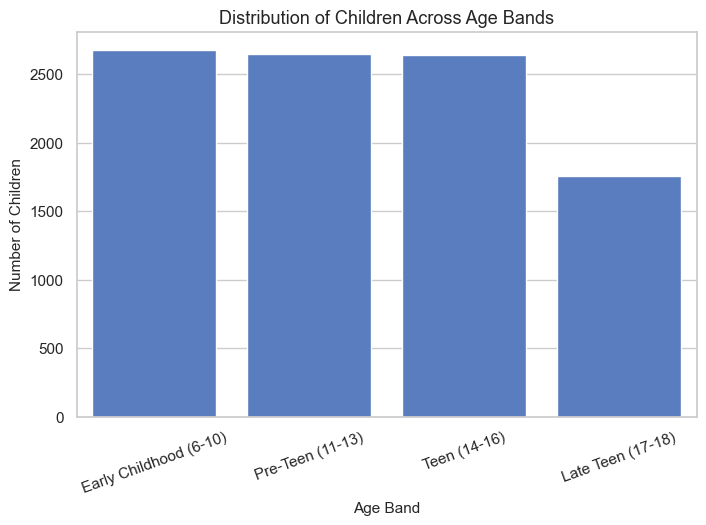

In [29]:
plt.figure(figsize=(8,5))
sns.countplot(x='Age_Band', data=df)
plt.title("Distribution of Children Across Age Bands")
plt.xlabel("Age Band")
plt.ylabel("Number of Children")
plt.xticks(rotation=20)
plt.show()

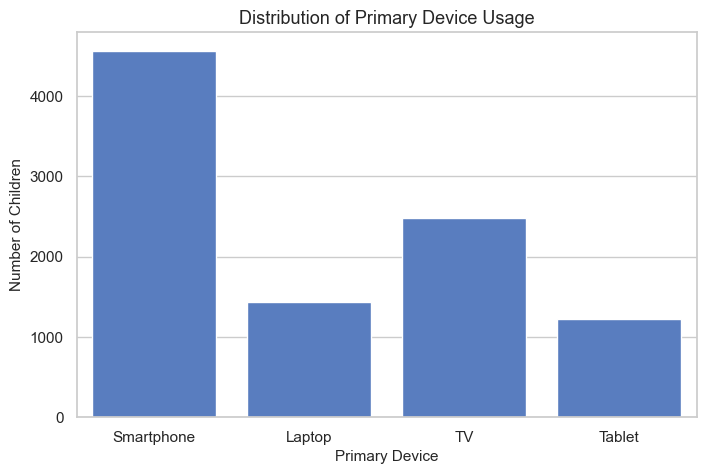

In [30]:
plt.figure(figsize=(8,5))
sns.countplot(x='Primary_Device', data=df)
plt.title("Distribution of Primary Device Usage")
plt.xlabel("Primary Device")
plt.ylabel("Number of Children")
plt.show()

### 3.8 Primary Device Distribution (Pie Chart)

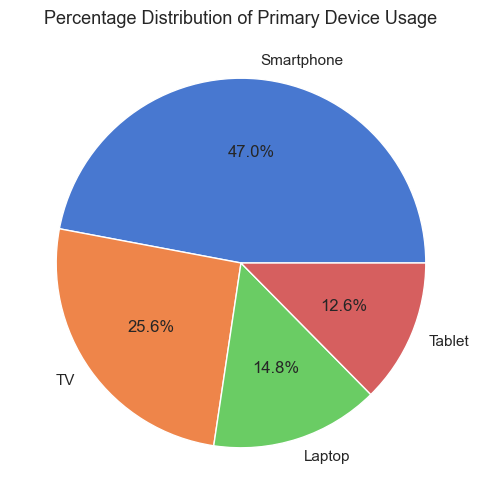

In [31]:
device_counts = df['Primary_Device'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(device_counts.values,
        labels=device_counts.index,
        autopct='%1.1f%%')
plt.title("Percentage Distribution of Primary Device Usage")
plt.show()

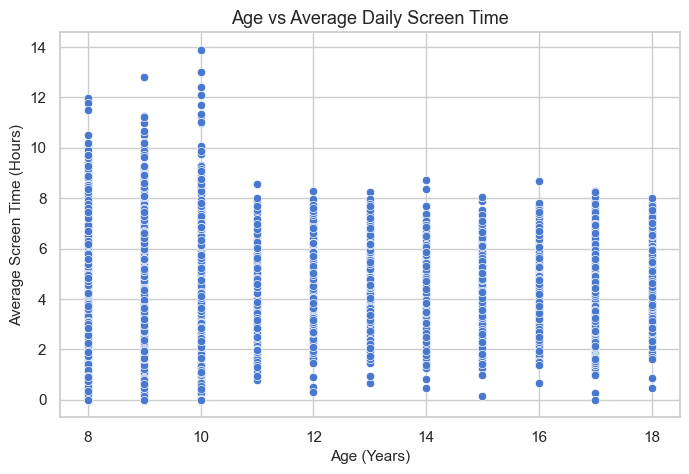

In [32]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Age vs Average Daily Screen Time")
plt.xlabel("Age (Years)")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

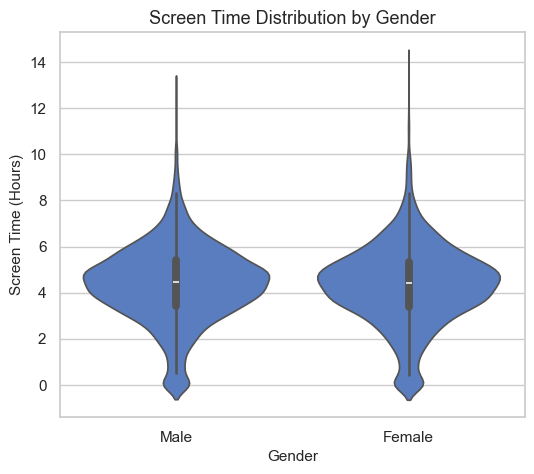

In [33]:
plt.figure(figsize=(6,5))
sns.violinplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Screen Time (Hours)")
plt.show()

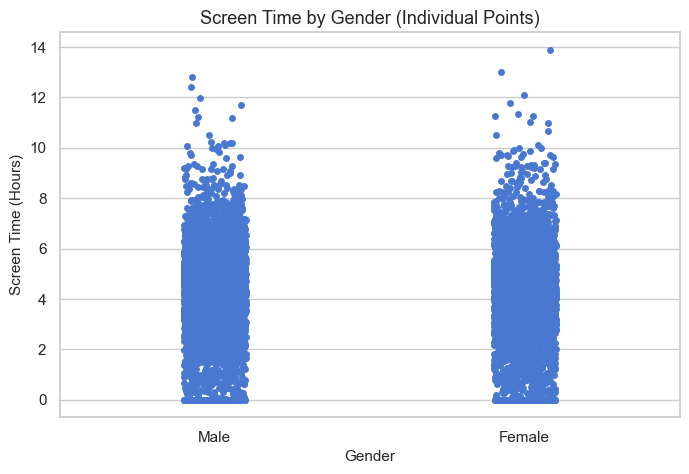

In [34]:
plt.figure(figsize=(8,5))
sns.stripplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time by Gender (Individual Points)")
plt.xlabel("Gender")
plt.ylabel("Screen Time (Hours)")
plt.show()

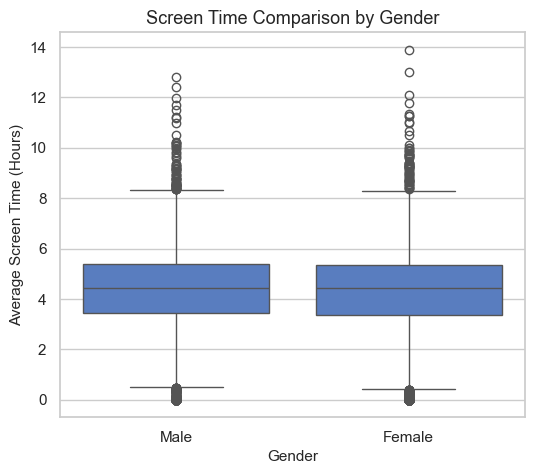

In [35]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time Comparison by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

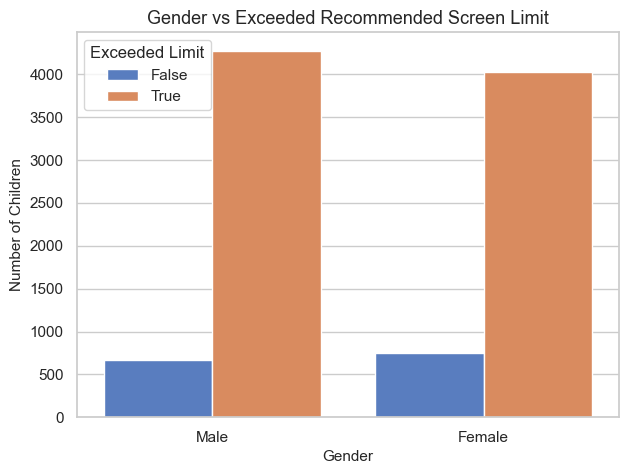

In [36]:
plt.figure(figsize=(7,5))
sns.countplot(x='Gender', hue='Exceeded_Recommended_Limit', data=df)
plt.title("Gender vs Exceeded Recommended Screen Limit")
plt.xlabel("Gender")
plt.ylabel("Number of Children")
plt.legend(title="Exceeded Limit")
plt.show()

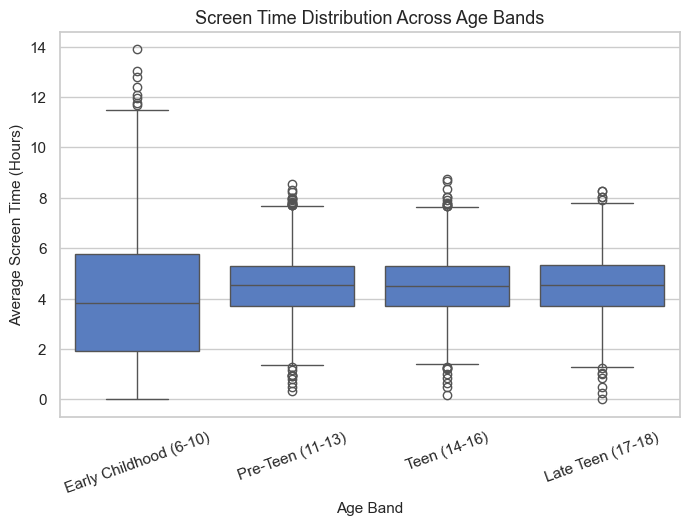

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Age_Band', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time Distribution Across Age Bands")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (Hours)")
plt.xticks(rotation=20)
plt.show()

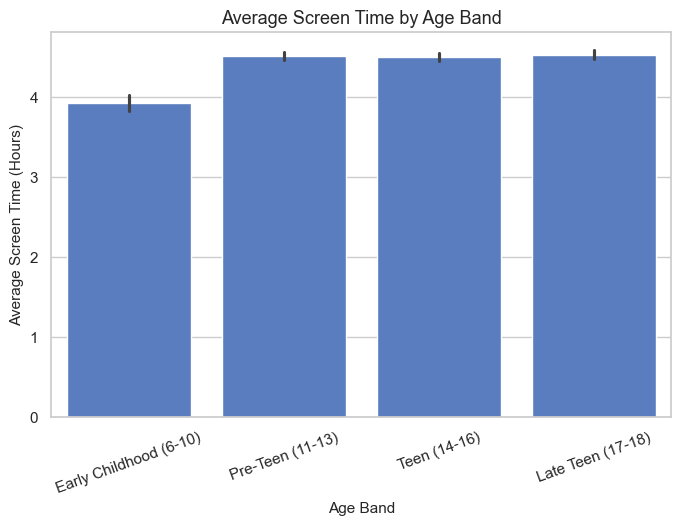

In [38]:
plt.figure(figsize=(8,5))
sns.barplot(x='Age_Band', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Average Screen Time by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (Hours)")
plt.xticks(rotation=20)
plt.show()

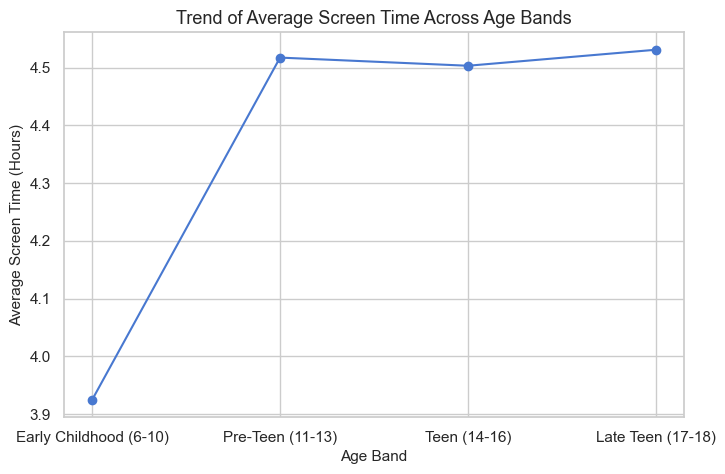

In [39]:
age_screen_avg = df.groupby('Age_Band')['Avg_Daily_Screen_Time_hr'].mean()

plt.figure(figsize=(8,5))
plt.plot(age_screen_avg.index, age_screen_avg.values, marker='o')
plt.title("Trend of Average Screen Time Across Age Bands")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (Hours)")
plt.grid(True)
plt.show()

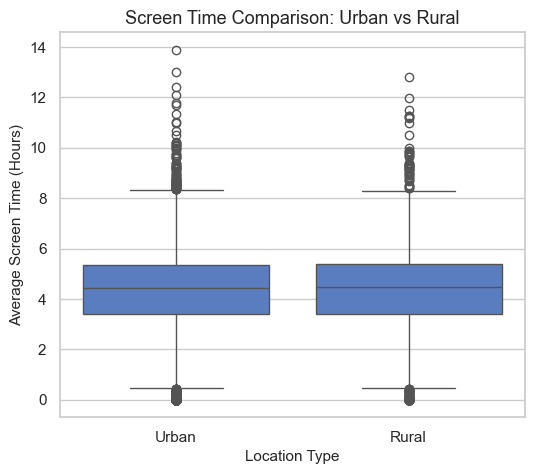

In [40]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Urban_or_Rural', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time Comparison: Urban vs Rural")
plt.xlabel("Location Type")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

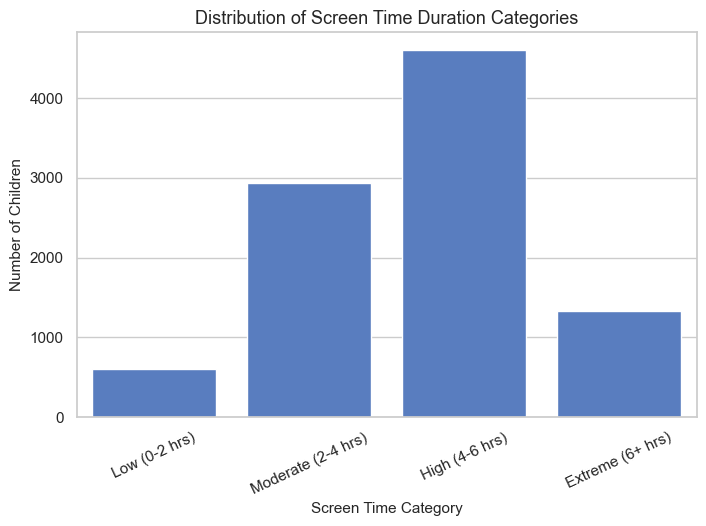

In [41]:
plt.figure(figsize=(8,5))
sns.countplot(x='Duration_Category', data=df)
plt.title("Distribution of Screen Time Duration Categories")
plt.xlabel("Screen Time Category")
plt.ylabel("Number of Children")
plt.xticks(rotation=25)
plt.show()

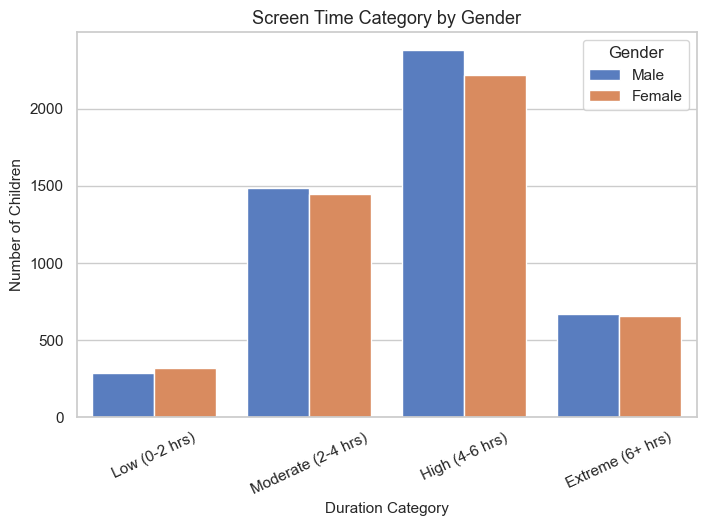

In [42]:
plt.figure(figsize=(8,5))
sns.countplot(x='Duration_Category', hue='Gender', data=df)
plt.title("Screen Time Category by Gender")
plt.xlabel("Duration Category")
plt.ylabel("Number of Children")
plt.xticks(rotation=25)
plt.show()

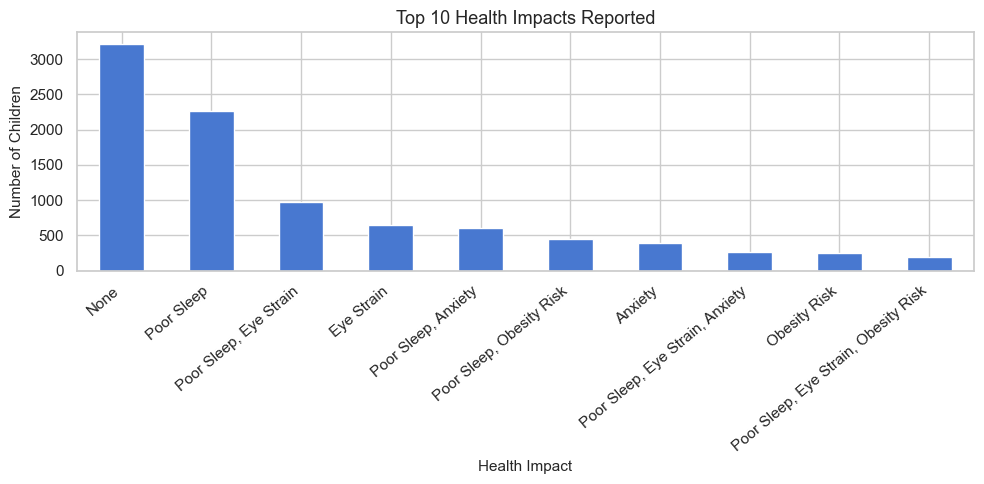

In [43]:
health_counts = df['Health_Impacts'].value_counts().head(10)

plt.figure(figsize=(10,5))
health_counts.plot(kind='bar')
plt.title("Top 10 Health Impacts Reported")
plt.xlabel("Health Impact")
plt.ylabel("Number of Children")
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

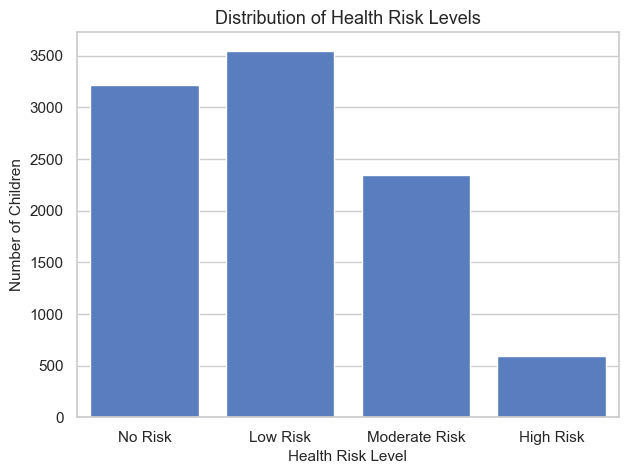

In [44]:
plt.figure(figsize=(7,5))
sns.countplot(x='Health_Risk_Level', data=df, order=['No Risk','Low Risk','Moderate Risk','High Risk'])
plt.title("Distribution of Health Risk Levels")
plt.xlabel("Health Risk Level")
plt.ylabel("Number of Children")
plt.show()

Week 3
- Older age bands (Teen & Late Teen) show higher screen time compared to Early Childhood.
- Urban children use screens slightly more than Rural children.
- A significant portion of children exceed the recommended screen time limit.
- 'Poor Sleep' is the dominant health impact, often combined with Eye Strain or Anxiety.

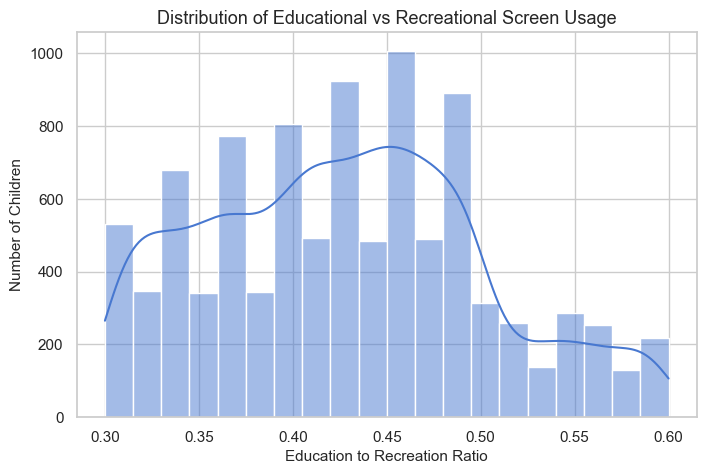

In [45]:
#week 4
plt.figure(figsize=(8,5))
sns.histplot(df['Educational_to_Recreational_Ratio'], bins=20, kde=True)
plt.title("Distribution of Educational vs Recreational Screen Usage")
plt.xlabel("Education to Recreation Ratio")
plt.ylabel("Number of Children")
plt.show()

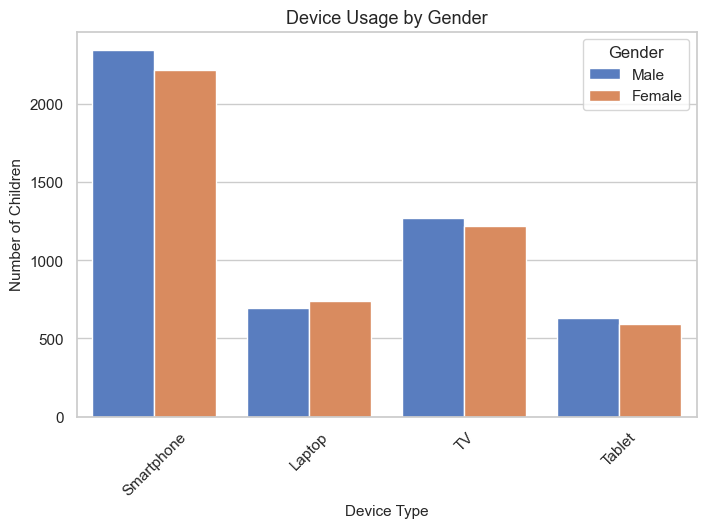

In [46]:
plt.figure(figsize=(8,5))
sns.countplot(x='Primary_Device', hue='Gender', data=df)
plt.title("Device Usage by Gender")
plt.xlabel("Device Type")
plt.ylabel("Number of Children")
plt.xticks(rotation=45)
plt.show()

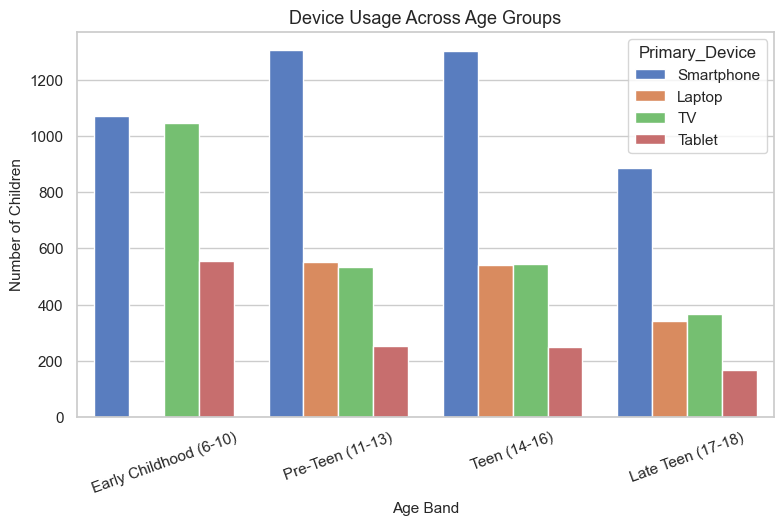

In [47]:
plt.figure(figsize=(9,5))
sns.countplot(x='Age_Band', hue='Primary_Device', data=df)
plt.title("Device Usage Across Age Groups")
plt.xlabel("Age Band")
plt.ylabel("Number of Children")
plt.xticks(rotation=20)
plt.show()

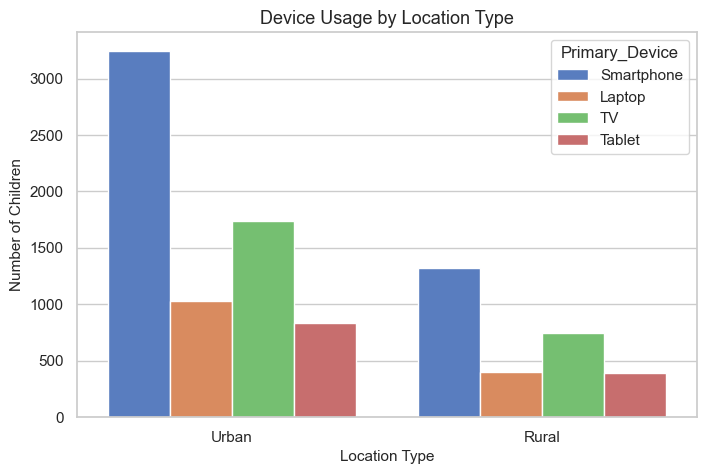

In [48]:
plt.figure(figsize=(8,5))
sns.countplot(x='Urban_or_Rural', hue='Primary_Device', data=df)
plt.title("Device Usage by Location Type")
plt.xlabel("Location Type")
plt.ylabel("Number of Children")
plt.show()

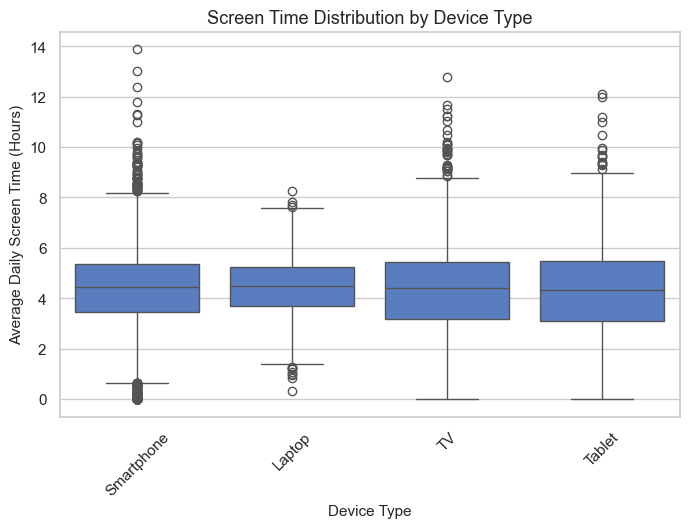

In [49]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Primary_Device', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time Distribution by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Average Daily Screen Time (Hours)")
plt.xticks(rotation=45)
plt.show()

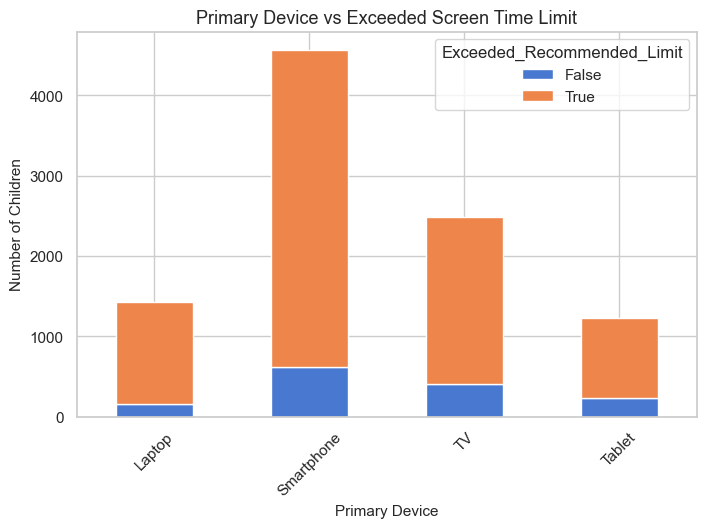

In [50]:
ct = pd.crosstab(df['Primary_Device'], df['Exceeded_Recommended_Limit'])

ct.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Primary Device vs Exceeded Screen Time Limit")
plt.xlabel("Primary Device")
plt.ylabel("Number of Children")
plt.xticks(rotation=45)
plt.show()

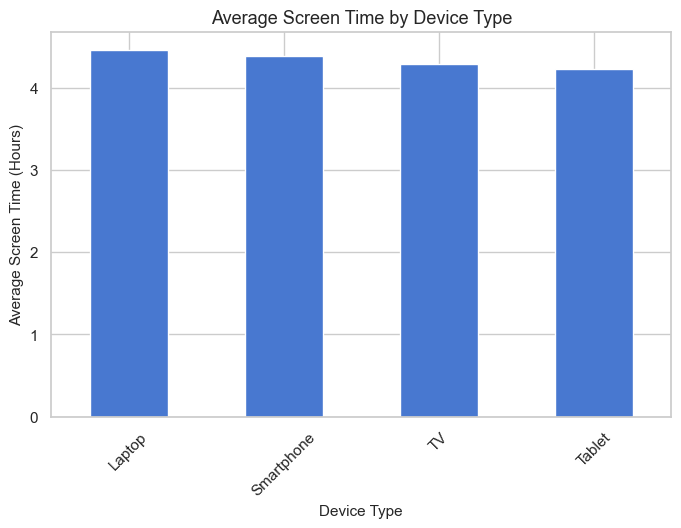

In [51]:
device_peak = df.groupby('Primary_Device')['Avg_Daily_Screen_Time_hr'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
device_peak.plot(kind='bar')
plt.title("Average Screen Time by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Average Screen Time (Hours)")
plt.xticks(rotation=45)
plt.show()

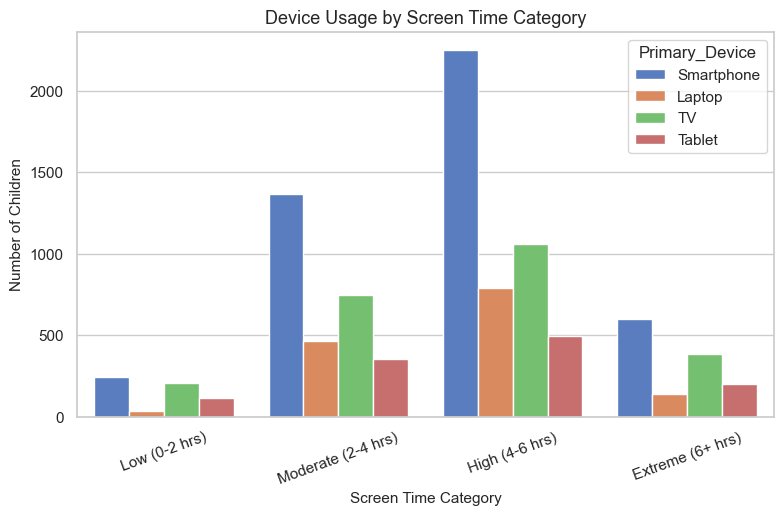

In [52]:
plt.figure(figsize=(9,5))
sns.countplot(x='Duration_Category', hue='Primary_Device', data=df)
plt.title("Device Usage by Screen Time Category")
plt.xlabel("Screen Time Category")
plt.ylabel("Number of Children")
plt.xticks(rotation=20)
plt.show()

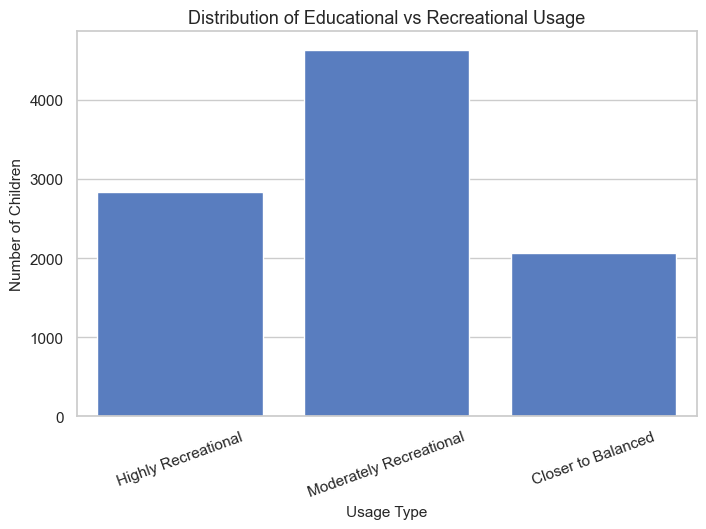

In [53]:
plt.figure(figsize=(8,5))
sns.countplot(x='Usage_Type', data=df)
plt.title("Distribution of Educational vs Recreational Usage")
plt.xlabel("Usage Type")
plt.ylabel("Number of Children")
plt.xticks(rotation=20)
plt.show()

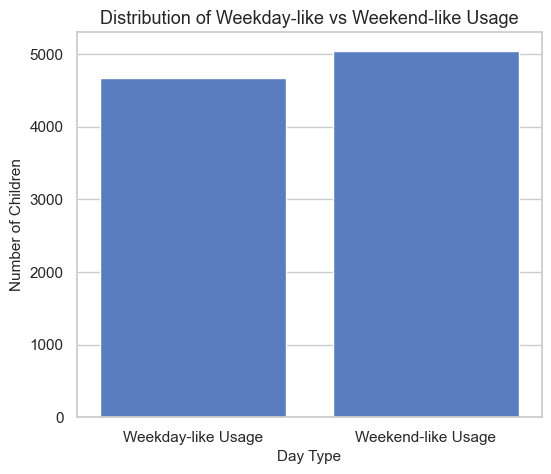

In [54]:
plt.figure(figsize=(6,5))
sns.countplot(x='Day_Type_Flag', data=df)
plt.title("Distribution of Weekday-like vs Weekend-like Usage")
plt.xlabel("Day Type")
plt.ylabel("Number of Children")
plt.show()

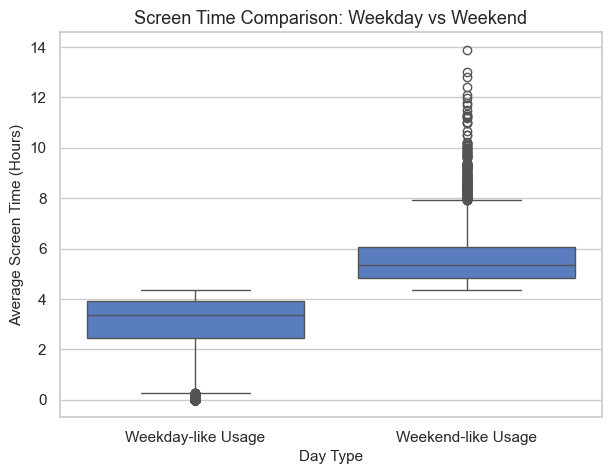

In [55]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Day_Type_Flag', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time Comparison: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

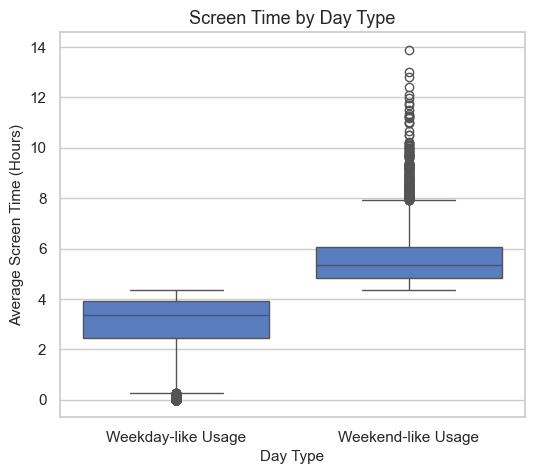

In [56]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Day_Type_Flag', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time by Day Type")
plt.xlabel("Day Type")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

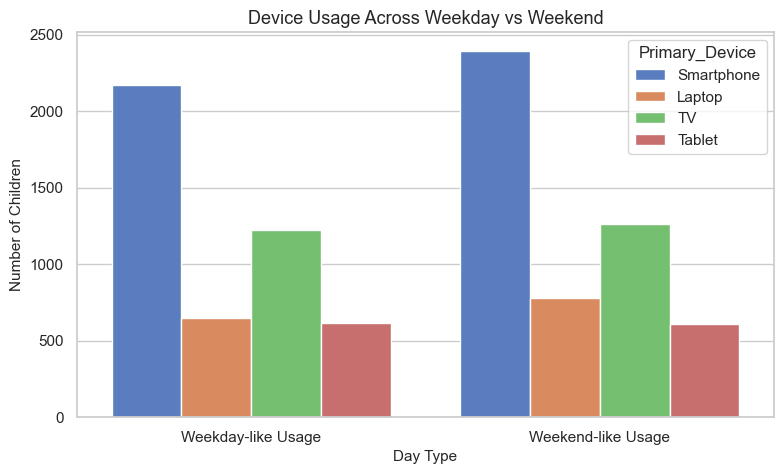

In [57]:
plt.figure(figsize=(9,5))
sns.countplot(x='Day_Type_Flag', hue='Primary_Device', data=df)
plt.title("Device Usage Across Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Number of Children")
plt.show()

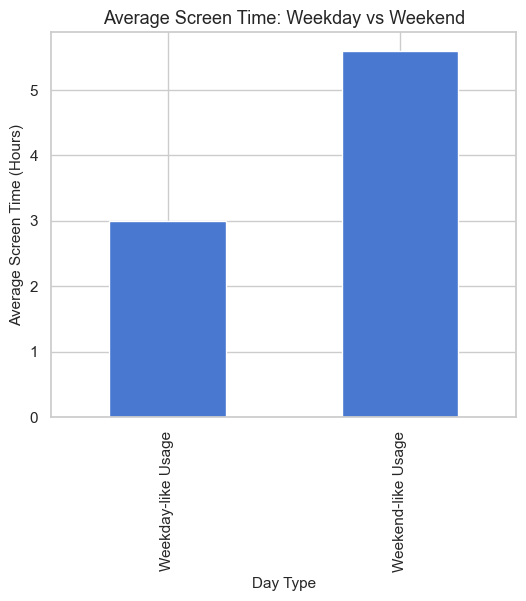

In [58]:
day_peak = df.groupby('Day_Type_Flag')['Avg_Daily_Screen_Time_hr'].mean()

plt.figure(figsize=(6,5))
day_peak.plot(kind='bar')
plt.title("Average Screen Time: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

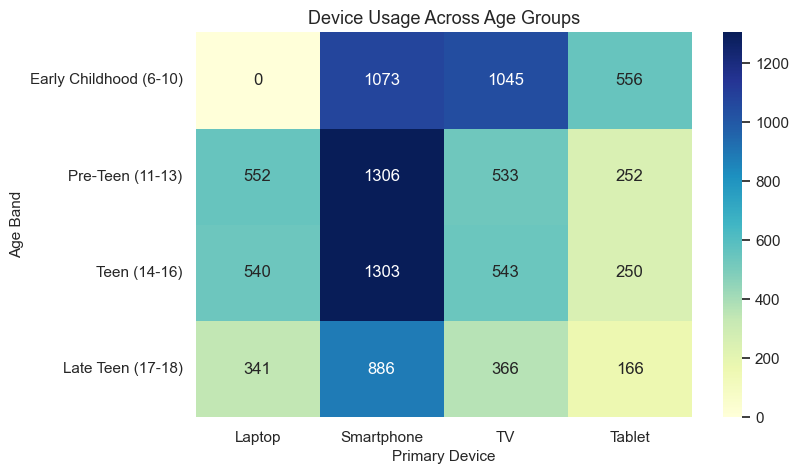

In [59]:
device_age = pd.crosstab(df['Age_Band'], df['Primary_Device'])

plt.figure(figsize=(8,5))
sns.heatmap(device_age, annot=True, cmap='YlGnBu', fmt='d')
plt.title("Device Usage Across Age Groups")
plt.xlabel("Primary Device")
plt.ylabel("Age Band")
plt.show()

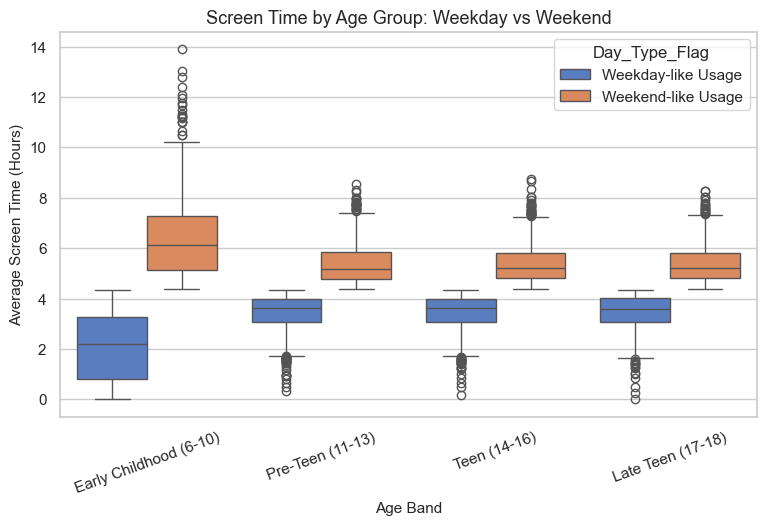

In [60]:
plt.figure(figsize=(9,5))
sns.boxplot(x='Age_Band',
            y='Avg_Daily_Screen_Time_hr',
            hue='Day_Type_Flag',
            data=df)
plt.title("Screen Time by Age Group: Weekday vs Weekend")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (Hours)")
plt.xticks(rotation=20)
plt.show()

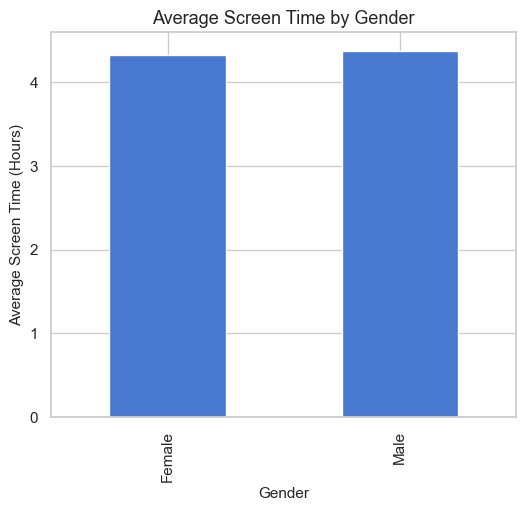

In [61]:
gender_peak = df.groupby('Gender')['Avg_Daily_Screen_Time_hr'].mean()

plt.figure(figsize=(6,5))
gender_peak.plot(kind='bar')
plt.title("Average Screen Time by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

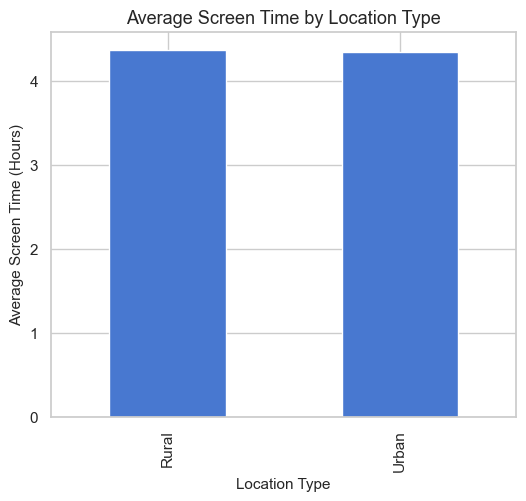

In [62]:
location_peak = df.groupby('Urban_or_Rural')['Avg_Daily_Screen_Time_hr'].mean()

plt.figure(figsize=(6,5))
location_peak.plot(kind='bar')
plt.title("Average Screen Time by Location Type")
plt.xlabel("Location Type")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

Week 4 Insights
- Smartphone is the most dominant device across all age groups and genders.
- TV usage is relatively higher in younger age bands (Early Childhood), while Laptops gain popularity in Teen & Late Teen groups.
- Weekend-like usage (above-average screen time) accounts for a notable portion of the dataset — suggesting habitual over-usage.
- Rural children are nearly as engaged as Urban in device usage, with Smartphones dominating both.
- Educational usage is a minority — most children tilt heavily toward recreational content.

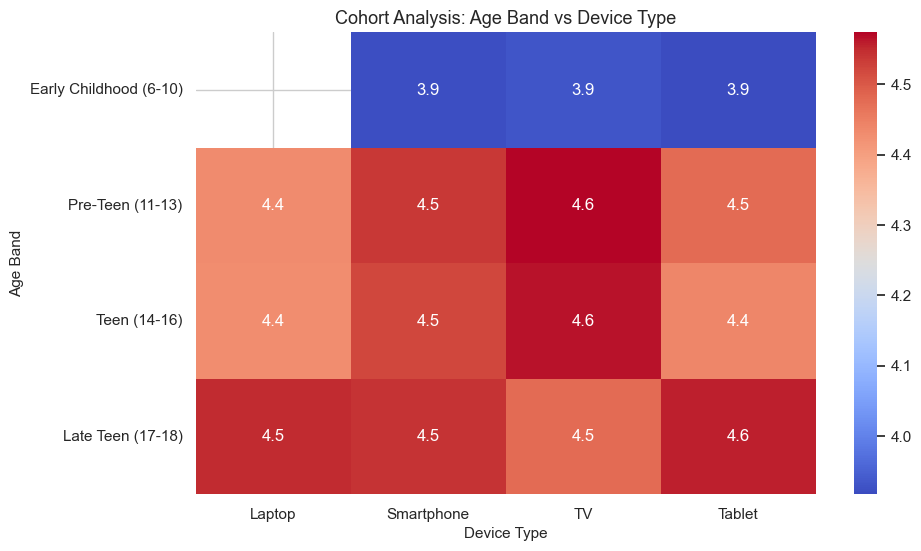

In [63]:
#week 5
age_device_cohort = df.groupby(['Age_Band','Primary_Device'])['Avg_Daily_Screen_Time_hr'].mean().unstack()

plt.figure(figsize=(10,6))
sns.heatmap(age_device_cohort, annot=True, cmap='coolwarm')
plt.title("Cohort Analysis: Age Band vs Device Type")
plt.xlabel("Device Type")
plt.ylabel("Age Band")
plt.show()

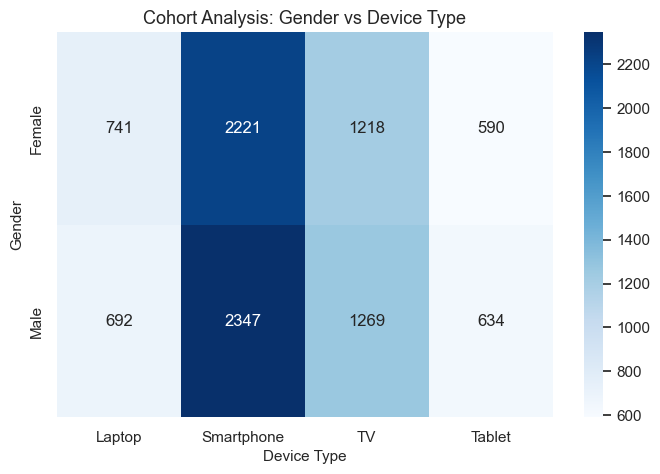

In [64]:
gender_device_cohort = pd.crosstab(df['Gender'], df['Primary_Device'])

plt.figure(figsize=(8,5))
sns.heatmap(gender_device_cohort, annot=True, cmap="Blues", fmt='d')
plt.title("Cohort Analysis: Gender vs Device Type")
plt.xlabel("Device Type")
plt.ylabel("Gender")
plt.show()

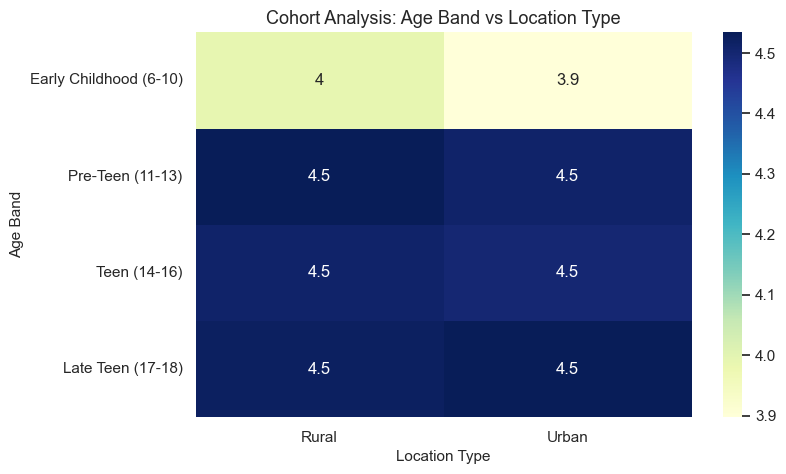

In [65]:
age_location_cohort = df.groupby(['Age_Band','Urban_or_Rural'])['Avg_Daily_Screen_Time_hr'].mean().unstack()

plt.figure(figsize=(8,5))
sns.heatmap(age_location_cohort, annot=True, cmap='YlGnBu')
plt.title("Cohort Analysis: Age Band vs Location Type")
plt.xlabel("Location Type")
plt.ylabel("Age Band")
plt.show()

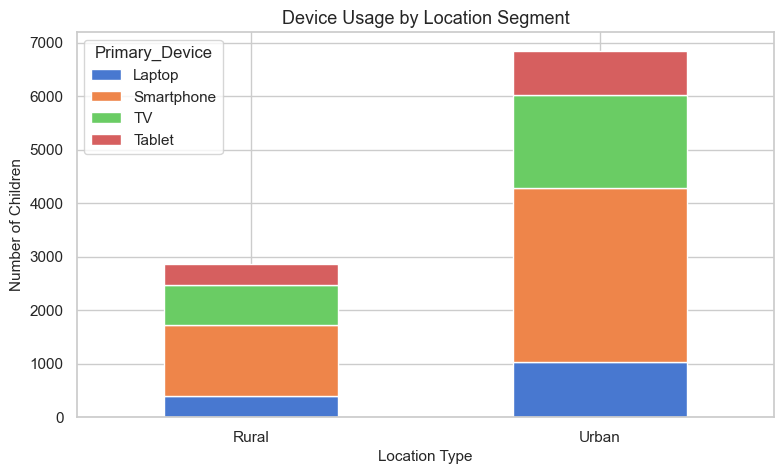

In [66]:
location_device_segment = pd.crosstab(df['Urban_or_Rural'], df['Primary_Device'])

location_device_segment.plot(kind='bar', stacked=True, figsize=(9,5))
plt.title("Device Usage by Location Segment")
plt.xlabel("Location Type")
plt.ylabel("Number of Children")
plt.xticks(rotation=0)
plt.show()

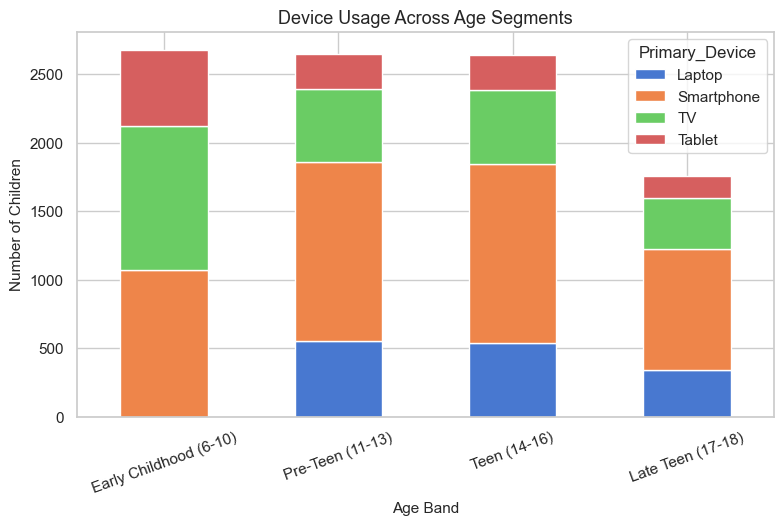

In [67]:
age_device_segment = pd.crosstab(df['Age_Band'], df['Primary_Device'])

age_device_segment.plot(kind='bar', stacked=True, figsize=(9,5))
plt.title("Device Usage Across Age Segments")
plt.xlabel("Age Band")
plt.ylabel("Number of Children")
plt.xticks(rotation=20)
plt.show()

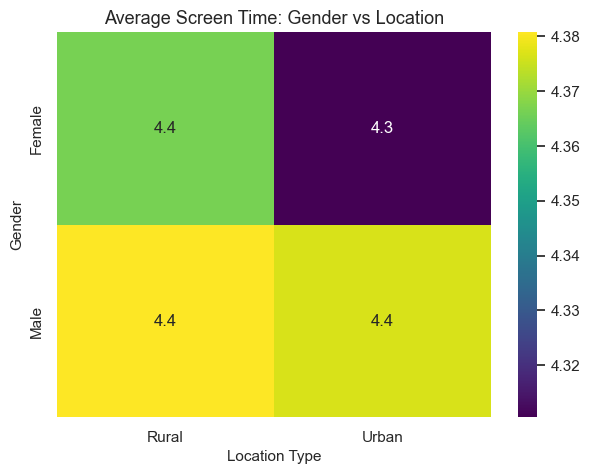

In [68]:
gender_location_cohort = df.groupby(['Gender','Urban_or_Rural'])['Avg_Daily_Screen_Time_hr'].mean().unstack()

plt.figure(figsize=(7,5))
sns.heatmap(gender_location_cohort, annot=True, cmap="viridis")
plt.title("Average Screen Time: Gender vs Location")
plt.xlabel("Location Type")
plt.ylabel("Gender")
plt.show()

<Figure size 900x500 with 0 Axes>

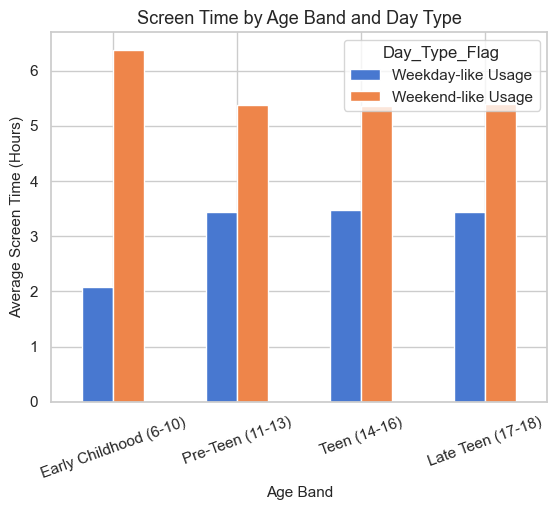

In [69]:
age_day_segment = df.groupby(['Age_Band','Day_Type_Flag'])['Avg_Daily_Screen_Time_hr'].mean().unstack()

plt.figure(figsize=(9,5))
age_day_segment.plot(kind='bar')
plt.title("Screen Time by Age Band and Day Type")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (Hours)")
plt.xticks(rotation=20)
plt.show()

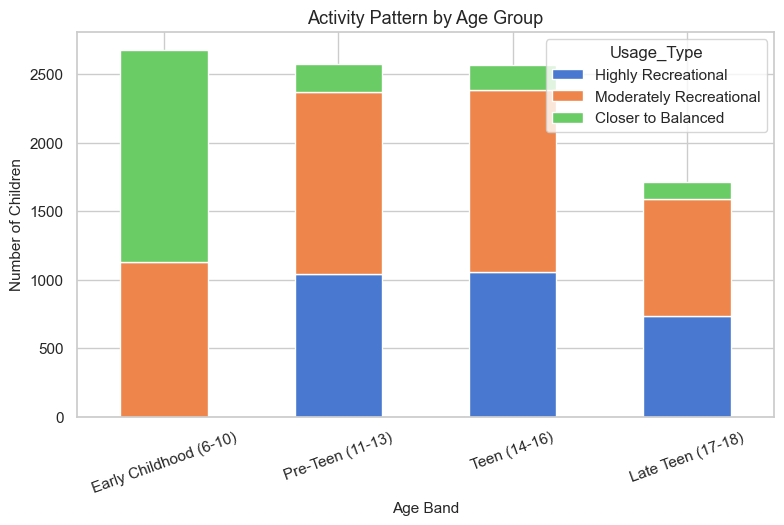

In [70]:
activity_cohort = pd.crosstab(df['Age_Band'], df['Usage_Type'])

activity_cohort.plot(kind='bar', stacked=True, figsize=(9,5))
plt.title("Activity Pattern by Age Group")
plt.xlabel("Age Band")
plt.ylabel("Number of Children")
plt.xticks(rotation=20)
plt.show()

<Figure size 900x500 with 0 Axes>

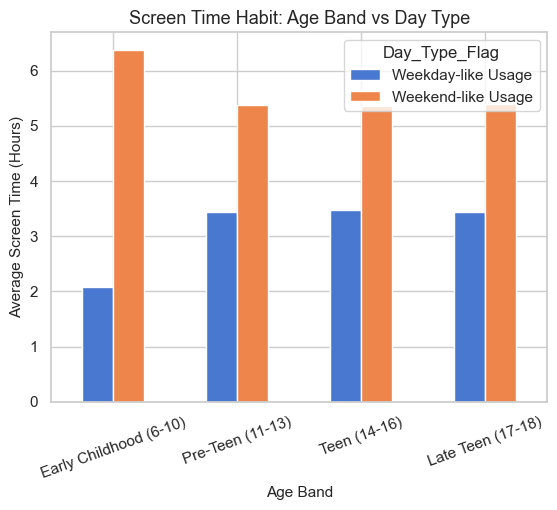

In [71]:
age_day_habit = df.groupby(['Age_Band','Day_Type_Flag'])['Avg_Daily_Screen_Time_hr'].mean().unstack()

plt.figure(figsize=(9,5))
age_day_habit.plot(kind='bar')
plt.title("Screen Time Habit: Age Band vs Day Type")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (Hours)")
plt.xticks(rotation=20)
plt.show()

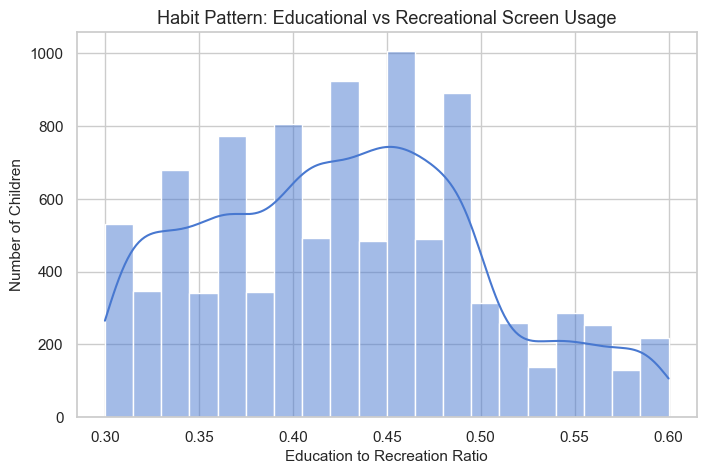

In [72]:
plt.figure(figsize=(8,5))
sns.histplot(df['Educational_to_Recreational_Ratio'], bins=20, kde=True)
plt.title("Habit Pattern: Educational vs Recreational Screen Usage")
plt.xlabel("Education to Recreation Ratio")
plt.ylabel("Number of Children")
plt.show()

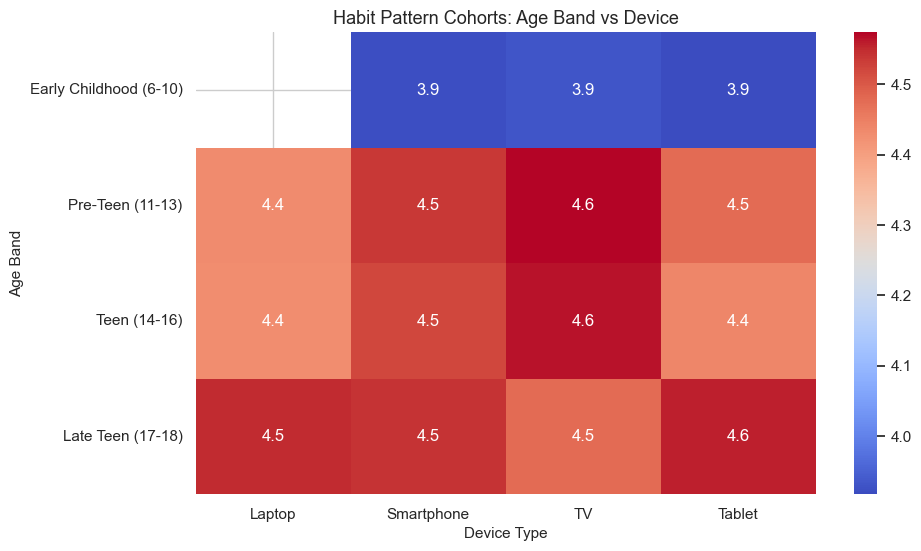

In [73]:
cohort_pattern = df.groupby(['Age_Band','Primary_Device'])['Avg_Daily_Screen_Time_hr'].mean().unstack()

plt.figure(figsize=(10,6))
sns.heatmap(cohort_pattern, annot=True, cmap='coolwarm')
plt.title("Habit Pattern Cohorts: Age Band vs Device")
plt.xlabel("Device Type")
plt.ylabel("Age Band")
plt.show()

Device_Portability
Portable           7225
Wall-Mount (TV)    2487
Name: count, dtype: int64


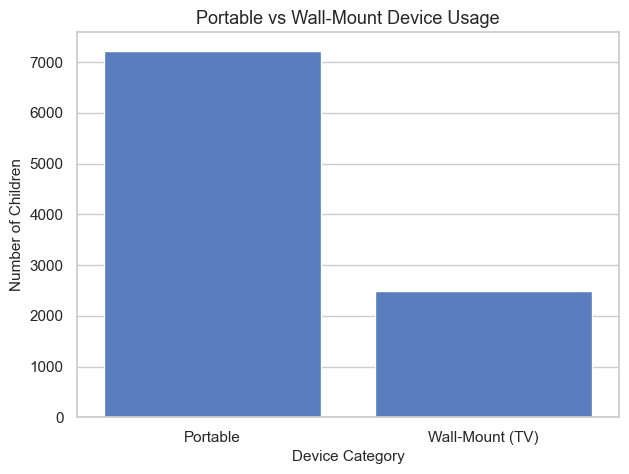

In [74]:
# Segmentation: Portable (Smartphone, Tablet, Laptop) vs Wall-Mount (TV)
df['Device_Portability'] = df['Primary_Device'].apply(
    lambda x: 'Portable' if x in ['Smartphone', 'Tablet', 'Laptop'] else 'Wall-Mount (TV)'
)

portability_counts = df['Device_Portability'].value_counts()
print(portability_counts)

plt.figure(figsize=(7,5))
sns.countplot(x='Device_Portability', data=df)
plt.title("Portable vs Wall-Mount Device Usage")
plt.xlabel("Device Category")
plt.ylabel("Number of Children")
plt.show()

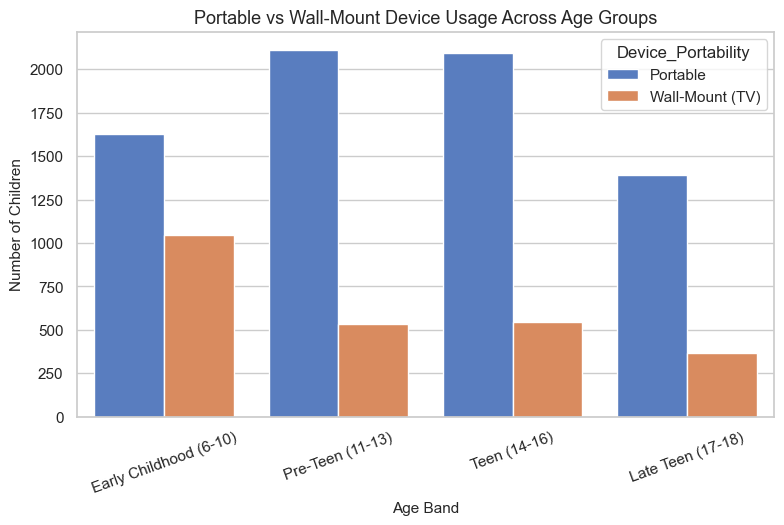

In [75]:
plt.figure(figsize=(9,5))
sns.countplot(x='Age_Band', hue='Device_Portability', data=df)
plt.title("Portable vs Wall-Mount Device Usage Across Age Groups")
plt.xlabel("Age Band")
plt.ylabel("Number of Children")
plt.xticks(rotation=20)
plt.show()

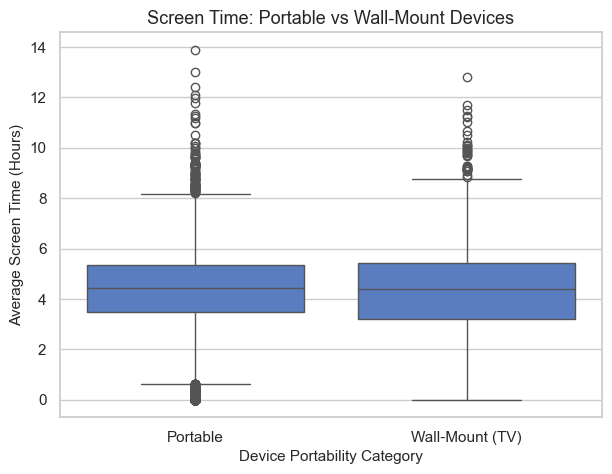

In [76]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Device_Portability', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time: Portable vs Wall-Mount Devices")
plt.xlabel("Device Portability Category")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

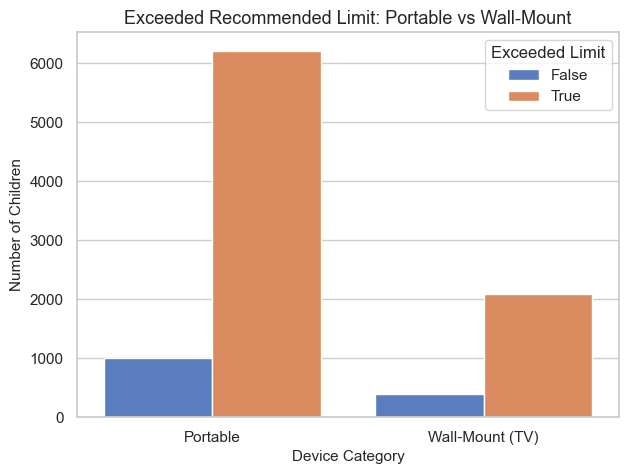

In [77]:
plt.figure(figsize=(7,5))
sns.countplot(x='Device_Portability', hue='Exceeded_Recommended_Limit', data=df)
plt.title("Exceeded Recommended Limit: Portable vs Wall-Mount")
plt.xlabel("Device Category")
plt.ylabel("Number of Children")
plt.legend(title="Exceeded Limit")
plt.show()

Health_Impacts
Poor Sleep      4868
Eye Strain      2382
Anxiety         1605
Obesity Risk    1217
Name: count, dtype: int64


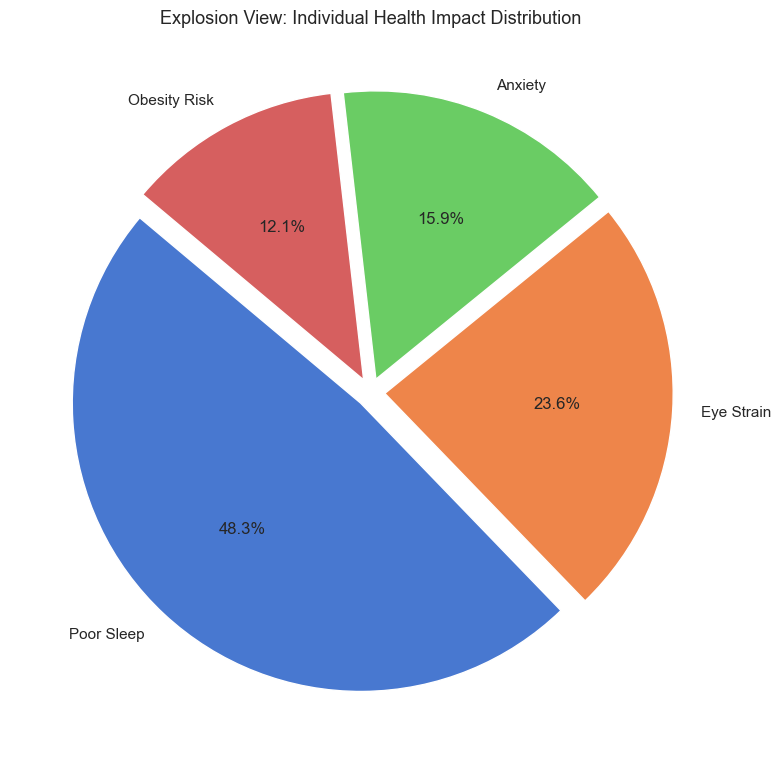

In [78]:
# Explode Health Impacts into individual entries
health_exploded = df['Health_Impacts'].str.split(',').explode().str.strip()
health_exploded = health_exploded[health_exploded != 'None']

health_freq = health_exploded.value_counts()
print(health_freq)

# Exploding pie chart
plt.figure(figsize=(8,8))
explode_vals = [0.05] * len(health_freq)
plt.pie(health_freq.values,
        labels=health_freq.index,
        autopct='%1.1f%%',
        explode=explode_vals,
        startangle=140)
plt.title("Explosion View: Individual Health Impact Distribution")
plt.tight_layout()
plt.show()

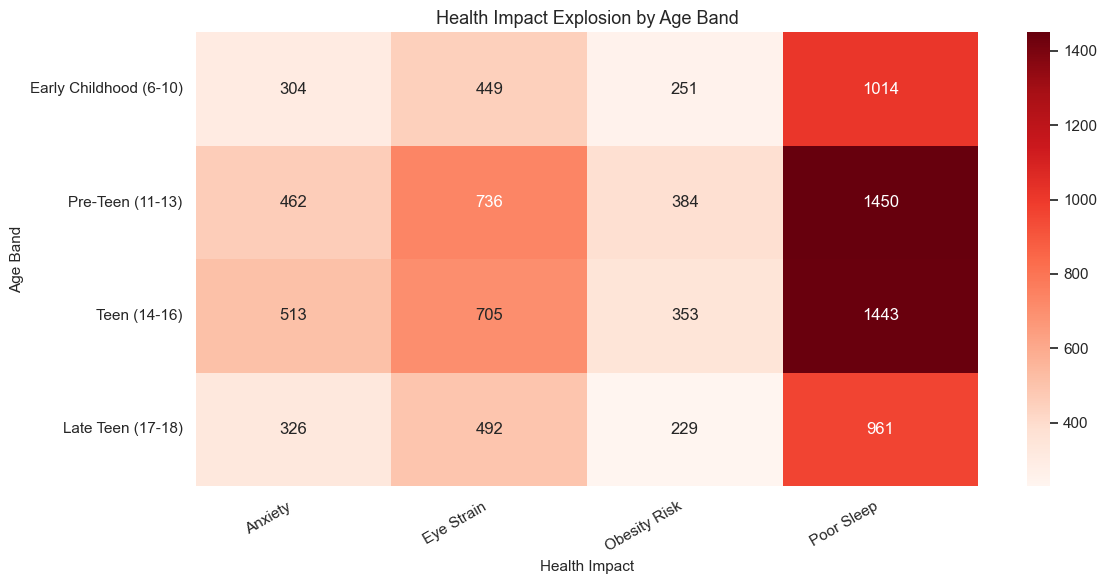

In [79]:
health_age = df[['Age_Band','Health_Impacts']].copy()
health_age['Health_Impacts'] = health_age['Health_Impacts'].str.split(',')
health_age = health_age.explode('Health_Impacts')
health_age['Health_Impacts'] = health_age['Health_Impacts'].str.strip()
health_age = health_age[health_age['Health_Impacts'] != 'None']

health_pivot = health_age.groupby(['Age_Band','Health_Impacts']).size().unstack(fill_value=0)

plt.figure(figsize=(12,6))
sns.heatmap(health_pivot, annot=True, fmt='d', cmap='Reds')
plt.title("Health Impact Explosion by Age Band")
plt.xlabel("Health Impact")
plt.ylabel("Age Band")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

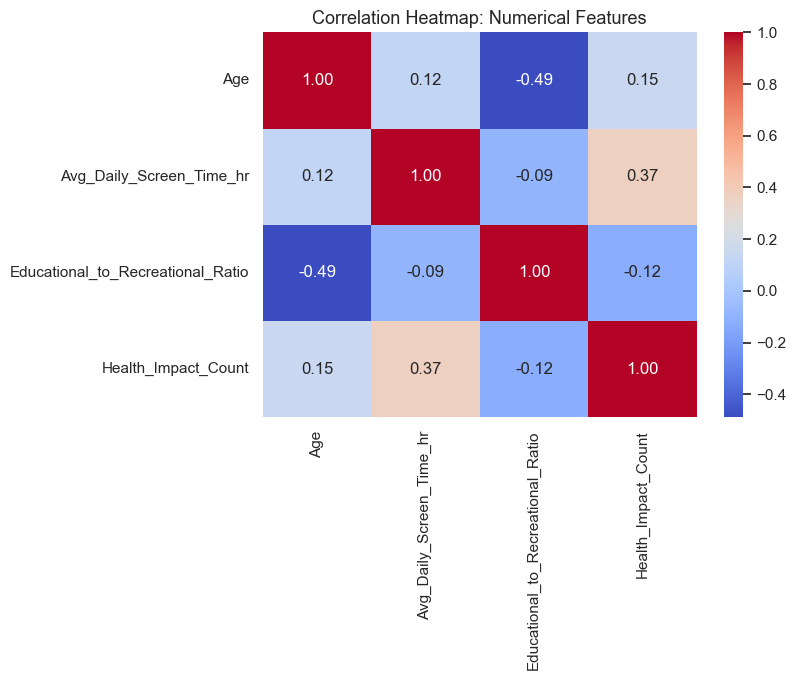

In [80]:
numeric_df = df[['Age','Avg_Daily_Screen_Time_hr','Educational_to_Recreational_Ratio','Health_Impact_Count']]

plt.figure(figsize=(7,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap: Numerical Features")
plt.show()

Week 5 Insights
- Portable devices (Smartphone + Tablet + Laptop) dominate across all age bands; TV usage is higher in younger children.
- The Portable vs Wall-Mount gap widens as children grow older — teens heavily favor Smartphones and Laptops.
- Exceeded recommended limits is significantly higher for portable device users.
- Explosion View shows 'Poor Sleep' is the single most prevalent health impact, affecting ~60%+ of children with any health issue.
- 'Anxiety' rises steeply in the Teen & Late Teen age bands — a concerning trend.
- Correlation analysis shows screen time has a mild positive correlation with age but weak correlation with Ed/Rec ratio.

In [81]:
#Week 6
# Summary table: Age Band × Urban/Rural
summary = df.groupby(['Age_Band','Urban_or_Rural']).agg(
    Avg_Screen_Time=('Avg_Daily_Screen_Time_hr','mean'),
    Pct_Exceeded=('Exceeded_Recommended_Limit','mean'),
    Avg_Ed_Rec_Ratio=('Educational_to_Recreational_Ratio','mean'),
    Count=('Age','count')
).round(2)

print(summary.to_string())

                                       Avg_Screen_Time  Pct_Exceeded  Avg_Ed_Rec_Ratio  Count
Age_Band               Urban_or_Rural                                                        
Early Childhood (6-10) Rural                      3.99          0.74               0.5    799
                       Urban                      3.90          0.74               0.5   1875
Pre-Teen (11-13)       Rural                      4.53          0.90               0.4    754
                       Urban                      4.51          0.90               0.4   1889
Teen (14-16)           Rural                      4.51          0.90               0.4    808
                       Urban                      4.50          0.90               0.4   1828
Late Teen (17-18)      Rural                      4.52          0.89               0.4    500
                       Urban                      4.53          0.90               0.4   1259


In [82]:
top_cohorts = df.groupby(['Age_Band','Primary_Device']).agg(
    Avg_Screen_Time=('Avg_Daily_Screen_Time_hr','mean'),
    Count=('Age','count'),
    Pct_Exceeded=('Exceeded_Recommended_Limit','mean')
).round(2).sort_values('Avg_Screen_Time', ascending=False)

print("Top 10 Cohorts by Average Screen Time:")
print(top_cohorts.head(10).to_string())

Top 10 Cohorts by Average Screen Time:
                                  Avg_Screen_Time  Count  Pct_Exceeded
Age_Band          Primary_Device                                      
Pre-Teen (11-13)  TV                         4.57    533          0.91
Teen (14-16)      TV                         4.56    543          0.92
Late Teen (17-18) Tablet                     4.56    166          0.91
                  Laptop                     4.55    341          0.90
Pre-Teen (11-13)  Smartphone                 4.54   1306          0.91
Late Teen (17-18) Smartphone                 4.54    886          0.90
Teen (14-16)      Smartphone                 4.52   1303          0.90
Pre-Teen (11-13)  Tablet                     4.48    252          0.86
Late Teen (17-18) TV                         4.48    366          0.89
Teen (14-16)      Tablet                     4.44    250          0.88


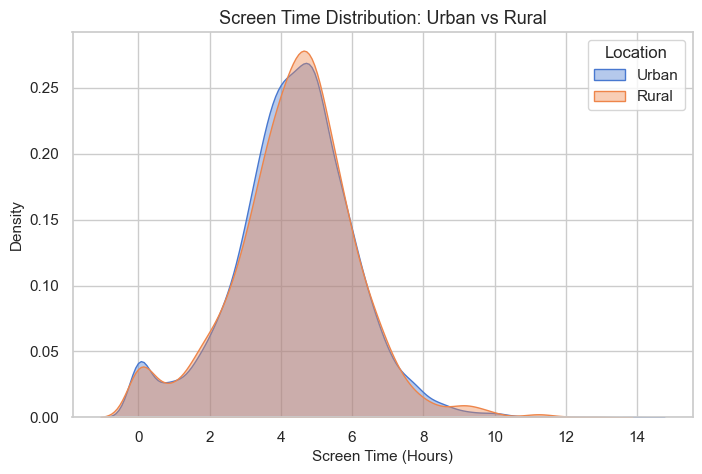

In [83]:
plt.figure(figsize=(8,5))
for loc in df['Urban_or_Rural'].unique():
    subset = df[df['Urban_or_Rural'] == loc]['Avg_Daily_Screen_Time_hr']
    sns.kdeplot(subset, label=loc, fill=True, alpha=0.4)
plt.title("Screen Time Distribution: Urban vs Rural")
plt.xlabel("Screen Time (Hours)")
plt.ylabel("Density")
plt.legend(title="Location")
plt.show()

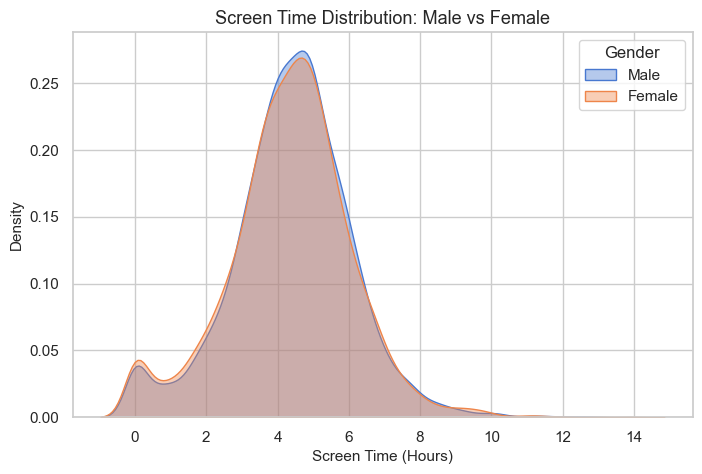

In [84]:
plt.figure(figsize=(8,5))
for gender in df['Gender'].unique():
    subset = df[df['Gender'] == gender]['Avg_Daily_Screen_Time_hr']
    sns.kdeplot(subset, label=gender, fill=True, alpha=0.4)
plt.title("Screen Time Distribution: Male vs Female")
plt.xlabel("Screen Time (Hours)")
plt.ylabel("Density")
plt.legend(title="Gender")
plt.show()

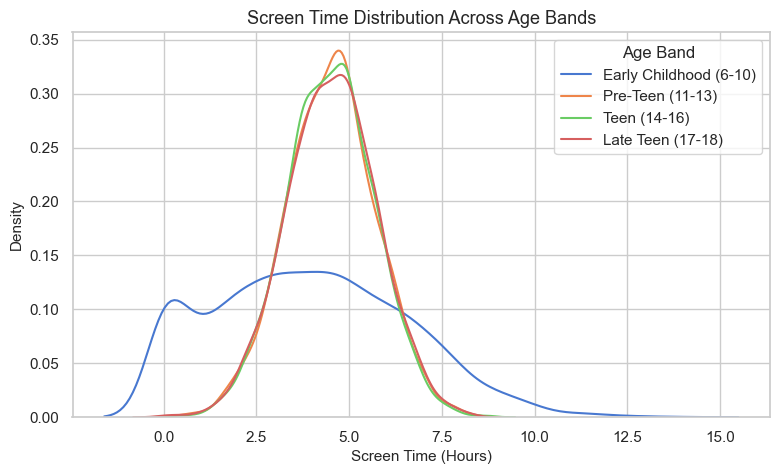

In [85]:
plt.figure(figsize=(9,5))
for band in df['Age_Band'].cat.categories:
    subset = df[df['Age_Band'] == band]['Avg_Daily_Screen_Time_hr']
    sns.kdeplot(subset, label=str(band), fill=False)
plt.title("Screen Time Distribution Across Age Bands")
plt.xlabel("Screen Time (Hours)")
plt.ylabel("Density")
plt.legend(title="Age Band")
plt.show()

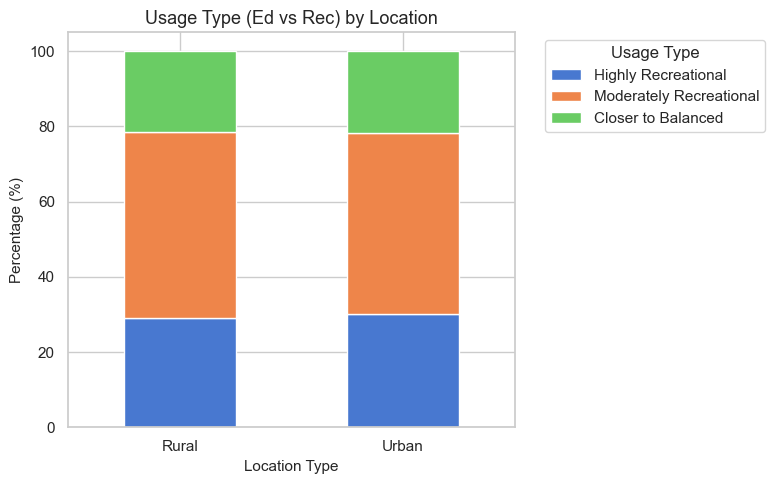

In [87]:
usage_location = pd.crosstab(df['Urban_or_Rural'], df['Usage_Type'], normalize='index') * 100

usage_location.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Usage Type (Ed vs Rec) by Location")
plt.xlabel("Location Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Usage Type", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

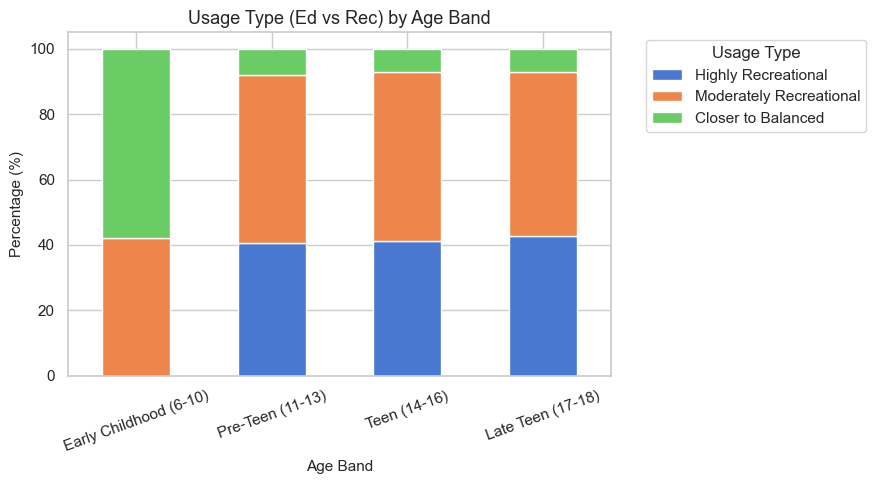

In [88]:
usage_age = pd.crosstab(df['Age_Band'], df['Usage_Type'], normalize='index') * 100

usage_age.plot(kind='bar', stacked=True, figsize=(9,5))
plt.title("Usage Type (Ed vs Rec) by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=20)
plt.legend(title="Usage Type", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

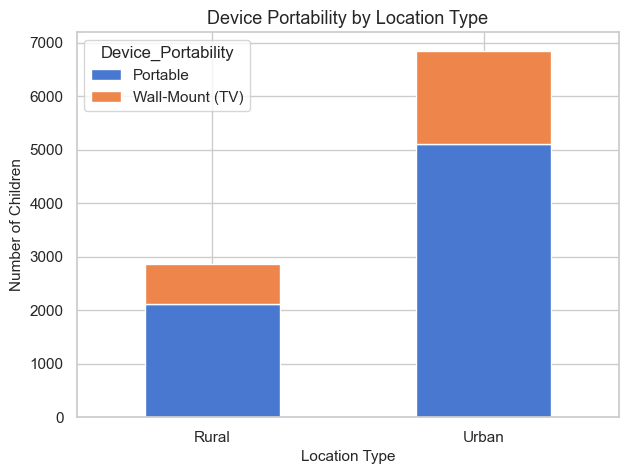

In [89]:
portability_loc = pd.crosstab(df['Urban_or_Rural'], df['Device_Portability'])

portability_loc.plot(kind='bar', stacked=True, figsize=(7,5))
plt.title("Device Portability by Location Type")
plt.xlabel("Location Type")
plt.ylabel("Number of Children")
plt.xticks(rotation=0)
plt.show()

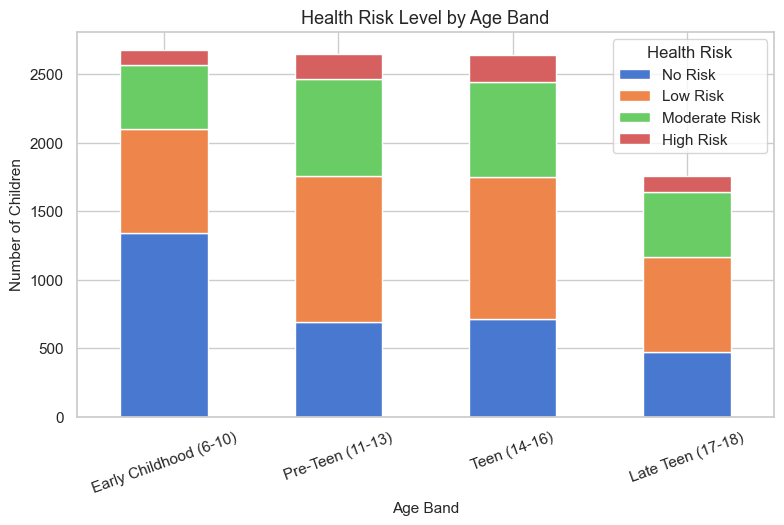

In [90]:
health_age_seg = pd.crosstab(df['Age_Band'], df['Health_Risk_Level'])

health_age_seg.plot(kind='bar', stacked=True, figsize=(9,5))
plt.title("Health Risk Level by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Number of Children")
plt.xticks(rotation=20)
plt.legend(title="Health Risk")
plt.show()

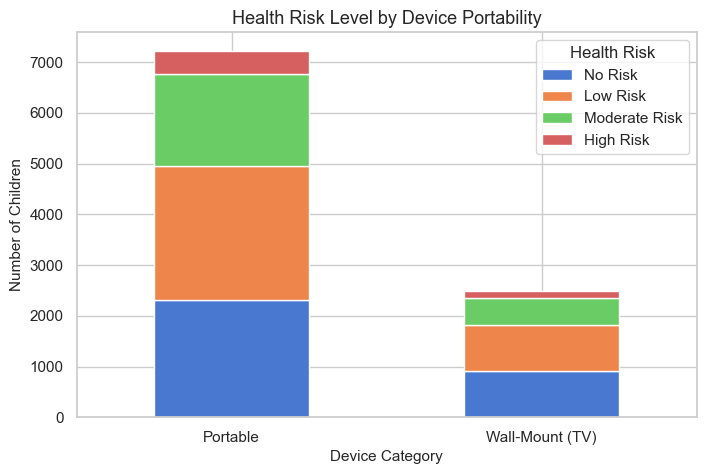

In [91]:
health_device = pd.crosstab(df['Device_Portability'], df['Health_Risk_Level'])

health_device.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Health Risk Level by Device Portability")
plt.xlabel("Device Category")
plt.ylabel("Number of Children")
plt.xticks(rotation=0)
plt.legend(title="Health Risk")
plt.show()

FINAL INSIGHTS

Demographic Patterns
- Age & Screen Time: Screen time increases with age. Late Teens (17–18) record the highest average daily usage, while Early Childhood (6–10) shows the lowest.
- Gender: Male children show marginally higher screen time on average; however, the difference is not dramatic — both genders have similar distribution shapes.
- Urban vs Rural: Urban children have slightly higher screen time, but Rural children are not far behind — digital penetration is strong across both settings.

Device Usage Patterns
- Smartphones dominate all age groups, especially in Teens and Late Teens.
- TV is preferred in Early Childhood (6–10), possibly due to parental supervision patterns.
- Laptops grow in relevance for Teen and Late Teen groups, likely tied to academic and gaming use.
- Portable devices (Smartphone + Tablet + Laptop) account for the vast majority of usage and are more strongly associated with exceeding recommended limits than wall-mount TV.

Educational vs Recreational Balance
- The majority of children lean toward Highly Recreational or Moderately Recreational usage.
- Educational usage is more balanced in Late Teen groups — possibly due to academic requirements.
- Urban children show a marginally higher proportion of balanced/educational usage than Rural children.

Health Impact Insights 
- Poor Sleep is the most prevalent health impact, present in the majority of reported cases.
- Eye Strain commonly co-occurs with Poor Sleep.
- Anxiety is disproportionately high in Teens (14–16) and Late Teens (17–18), reflecting the emotional toll of high recreational screen time.
- High-risk children (3+ health impacts) are clustered in the Smartphone + Teen cohort.